In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Nice"
away= "Nantes"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
22,Nice,Montpellier,2025-02-23,W,H,2,0,2,2,0,...,1.7,2.1,0.2,0.2,0.3,0.11,0,0.0,0.04,0.0
23,Nice,Saint-Étienne,2025-03-01,W,A,3,1,2,2,0,...,1.6,1.1,0.2,0.2,-0.6,0.13,0,1.1,0.37,0.1
24,Nice,Lyon,2025-03-09,L,H,0,2,-2,0,0,...,1.1,1.5,-1.4,-1.4,-1.1,0.08,1,1.6,0.31,-0.4
25,Nice,Auxerre,2025-03-14,D,H,1,1,0,1,0,...,1.8,2.3,-1.0,-1.0,-0.8,0.11,1,1.4,0.35,0.4
26,Nice,Monaco,2025-03-29,L,A,1,2,-1,1,0,...,0.5,0.7,0.5,0.5,0.5,0.06,0,2.5,0.26,0.5


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
22,Montpellier,Nice,2025-02-23,L,A,0,2,-2,0,0,...,0.4,0.5,-0.6,-0.6,-0.4,0.04,1,1.5,0.26,-0.5
23,Saint-Étienne,Nice,2025-03-01,L,H,1,3,-2,1,0,...,0.9,1.8,0.1,0.1,0.1,0.07,0,2.7,0.34,0.7
24,Lyon,Nice,2025-03-09,W,A,2,0,2,2,0,...,1.0,0.5,0.9,0.9,1.0,0.14,0,0.3,0.11,0.3
25,Auxerre,Nice,2025-03-14,D,A,1,1,0,1,0,...,0.6,0.4,0.3,0.3,0.4,0.07,0,1.9,0.34,0.9
26,Monaco,Nice,2025-03-29,W,H,2,1,1,2,0,...,1.6,1.1,-0.4,0.4,0.4,0.10,0,0.7,0.17,-0.3


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
22,Nantes,Lens,2025-02-23,W,H,3,1,2,2,1,...,2.6,2.1,-0.9,-1.2,-1.6,0.23,0,1.4,0.21,0.4
23,Nantes,Marseille,2025-03-02,L,A,0,2,-2,0,0,...,0.8,0.5,-0.8,-0.8,-0.8,0.10,0,2.2,0.45,0.2
24,Nantes,Strasbourg,2025-03-09,L,H,0,1,-1,0,0,...,0.7,0.7,-0.8,-0.8,-0.7,0.07,0,0.3,0.30,-0.7
25,Nantes,Lille,2025-03-15,W,H,1,0,1,1,0,...,0.7,1.1,-0.2,-0.2,0.3,0.12,0,1.0,0.34,1.0
26,Nantes,Le Havre,2025-03-30,L,A,2,3,-1,2,0,...,0.6,0.7,1.2,1.2,1.4,0.11,1,3.4,0.37,0.4


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
22,Lens,Nantes,2025-02-23,L,A,1,3,-2,0,1,...,0.5,0.8,-0.6,-1.0,-0.5,0.08,0,3.1,0.33,0.1
23,Marseille,Nantes,2025-03-02,W,H,2,0,2,2,0,...,1.7,1.3,-0.1,-0.1,-0.7,0.10,1,0.3,0.17,0.3
24,Strasbourg,Nantes,2025-03-09,W,A,1,0,1,1,0,...,0.7,1.1,0.0,0.0,0.3,0.11,0,0.3,0.16,0.3
25,Lille,Nantes,2025-03-15,L,A,0,1,-1,0,0,...,1.6,2.8,-1.6,-1.6,-1.6,0.12,0,1.0,0.48,0.0
26,Le Havre,Nantes,2025-03-30,W,H,3,2,1,1,2,...,2.0,2.3,-1.0,-1.4,-2.0,0.21,0,1.3,0.67,-0.7


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'G-PK', 'PK', 'PKatt', 'PKm', 'Poss', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
22,2,0,0,56,0,21,9,42.9,12,57.1,...,1.2,1.2,1.7,2.1,0.2,0.2,0.3,0.11,0,2
23,2,0,0,38,0,25,15,60.0,10,40.0,...,0.9,0.9,1.6,1.1,0.2,0.2,-0.6,0.13,0,3
24,0,0,0,37,0,16,6,37.5,8,50.0,...,0.3,0.3,1.1,1.5,-1.4,-1.4,-1.1,0.08,1,0
25,1,0,0,51,0,20,8,40.0,12,60.0,...,1.3,1.3,1.8,2.3,-1.0,-1.0,-0.8,0.11,1,1
26,1,0,0,42,0,28,10,35.7,13,46.4,...,-1.9,-1.1,0.5,0.7,0.5,0.5,0.5,0.06,0,1


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
22,0,0,0,44,0,7,4,57.1,2,28.6,...,-1.2,-1.2,0.4,0.5,-0.6,-0.6,-0.4,0.04,1,0
23,1,0,0,62,0,18,8,44.4,9,50.0,...,-0.9,-0.9,0.9,1.8,0.1,0.1,0.1,0.07,0,1
24,2,0,0,63,0,17,11,64.7,6,35.3,...,-0.3,-0.3,1.0,0.5,0.9,0.9,1.0,0.14,0,2
25,1,0,0,49,0,20,9,45.0,11,55.0,...,-1.3,-1.3,0.6,0.4,0.3,0.3,0.4,0.07,0,1
26,2,0,1,58,1,20,10,50.0,9,45.0,...,1.9,1.1,1.6,1.1,-0.4,0.4,0.4,0.10,0,2


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
22,2,1,0,35,1,34,16,47.1,16,47.1,...,2.3,2.2,2.6,2.1,-0.9,-1.2,-1.6,0.23,0,3
23,0,0,0,26,0,13,7,53.8,5,38.5,...,-1.3,-1.3,0.8,0.5,-0.8,-0.8,-0.8,0.10,0,0
24,0,0,0,40,0,11,5,45.5,6,54.5,...,-0.2,-0.2,0.7,0.7,-0.8,-0.8,-0.7,0.07,0,0
25,1,0,0,32,0,17,5,29.4,10,58.8,...,-0.4,-0.4,0.7,1.1,-0.2,-0.2,0.3,0.12,0,1
26,2,0,0,48,0,17,4,23.5,13,76.5,...,-3.2,-1.7,0.6,0.7,1.2,1.2,1.4,0.11,1,2


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
22,0,1,0,65,1,22,6,27.3,16,72.7,...,-2.3,-2.2,0.5,0.8,-0.6,-1.0,-0.5,0.08,0,1
23,2,0,0,74,0,26,9,34.6,15,57.7,...,1.3,1.3,1.7,1.3,-0.1,-0.1,-0.7,0.10,1,2
24,1,0,0,60,0,23,13,56.5,9,39.1,...,0.2,0.2,0.7,1.1,0.0,0.0,0.3,0.11,0,1
25,0,0,0,68,0,11,5,45.5,6,54.5,...,0.4,0.4,1.6,2.8,-1.6,-1.6,-1.6,0.12,0,0
26,1,2,0,52,2,13,2,15.4,10,76.9,...,3.2,1.7,2.0,2.3,-1.0,-1.4,-2.0,0.21,0,3


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
22,13,2,15.4,0,1,10.5,0,NaN,0,0,...,6,11,12,23,33,0,0.0,0.04,0.0,0
23,9,1,11.1,0,1,13.3,0,NaN,0,0,...,2,10,16,33,24,2,1.1,0.37,0.1,1
24,8,2,25.0,0,2,14.7,0,NaN,0,0,...,2,18,6,20,16,3,1.6,0.31,-0.4,2
25,10,0,0.0,0,0,7.0,0,NaN,0,0,...,4,11,13,30,22,0,1.4,0.35,0.4,1
26,9,0,0.0,1,0,7.6,1,100.0,0,0,...,4,9,8,28,31,2,2.5,0.26,0.5,2


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
22,11,1,9.1,0,1,11.0,0,NaN,0,0,...,4,6,6,27,26,1,1.5,0.26,-0.5,2
23,15,2,13.3,0,2,16.5,0,NaN,0,0,...,1,14,8,26,26,0,2.7,0.34,0.7,3
24,14,0,0.0,0,0,8.0,0,NaN,0,0,...,6,6,8,24,28,0,0.3,0.11,0.3,0
25,14,0,0.0,0,0,NaN,0,NaN,0,1,...,7,11,7,26,22,0,1.9,0.34,0.9,1
26,13,0,0.0,0,2,26.5,0,NaN,0,0,...,2,4,6,28,23,0,0.7,0.17,-0.3,1


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,20,2,10.0,0,0,4.6,0,NaN,0,0,...,3,7,5,23,33,0,1.3,0.22,1.3,0
1,28,1,3.6,0,0,5.8,0,NaN,0,0,...,5,10,10,31,41,0,0.3,0.11,0.3,0
2,27,3,11.1,0,1,9.3,0,NaN,0,0,...,2,12,8,32,46,1,0.5,0.14,-0.5,1
3,11,0,0.0,0,0,15.3,0,NaN,0,0,...,2,1,5,26,30,0,0.9,0.23,-1.1,2
4,12,2,16.7,1,0,10.7,0,0.0,0,0,...,1,3,5,25,21,0,0.6,0.00,-0.4,1


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,16,1,6.3,0,0,10.3,0,NaN,0,0,...,3,3,8,28,20,0,0.8,0.40,0.8,0
1,15,2,13.3,0,1,15.0,0,NaN,0,0,...,1,7,10,32,31,1,1.4,0.27,-0.6,2
2,9,1,11.1,1,2,19.4,0,0.0,0,0,...,1,7,4,19,12,0,1.5,0.16,-1.5,3
3,17,1,5.9,0,1,16.0,0,NaN,0,0,...,7,6,3,18,21,0,2.1,0.38,1.1,1
4,12,2,16.7,0,0,7.5,0,NaN,0,0,...,4,8,10,33,21,1,1.3,0.43,0.3,1


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
22,27,19,58.7,1,0,0,17,15,48
23,13,7,65.0,1,0,0,11,10,53
24,7,5,58.3,1,0,0,12,11,50
25,17,11,60.7,1,1,0,14,17,50
26,14,14,50.0,4,1,0,14,16,44


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
22,19,27,41.3,1,0,0,15,17,41
23,7,13,35.0,2,0,0,10,10,56
24,5,7,41.7,2,0,0,11,10,46
25,11,17,39.3,3,0,0,18,14,42
26,14,14,50.0,2,0,0,17,14,42


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
22,13,12,52.0,2,0,0,13,16,44
23,14,13,51.9,2,0,0,15,14,46
24,7,11,38.9,1,0,0,12,17,33
25,9,8,52.9,2,1,0,9,15,40
26,11,17,39.3,2,0,0,9,16,33


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
22,12,13,48.0,4,1,0,18,10,42
23,13,14,48.1,1,0,0,14,15,51
24,11,7,61.1,1,0,0,17,10,34
25,8,9,47.1,3,0,0,15,8,43
26,17,11,60.7,1,0,0,16,8,41


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
22,2,0,0,56,0,21,9,42.9,12,57.1,...,0.025,0.809835,-0.10,0.559762,0.1050,0.038730,0.25,0.50000,2.0,0.816497
23,2,0,0,38,0,25,15,60.0,10,40.0,...,-0.125,0.660177,-0.05,0.591608,0.1100,0.037417,0.25,0.50000,2.0,0.816497
24,0,0,0,37,0,16,6,37.5,8,50.0,...,0.150,0.412311,-0.05,0.591608,0.1250,0.026458,0.25,0.50000,2.5,0.577350
25,1,0,0,51,0,20,8,40.0,12,60.0,...,-0.100,0.886942,-0.20,0.787401,0.1200,0.033665,0.25,0.50000,2.0,1.414214
26,1,0,0,42,0,28,10,35.7,13,46.4,...,-0.500,0.824621,-0.55,0.602771,0.1075,0.020616,0.50,0.57735,1.5,1.290994


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
22,0,0,0,44,0,7,4,57.1,2,28.6,...,-0.525,0.639661,-0.550,0.645497,0.0775,0.032016,0.25,0.5,0.5,0.577350
23,1,0,0,62,0,18,8,44.4,9,50.0,...,-0.475,0.618466,-0.475,0.639661,0.0750,0.035119,0.25,0.5,0.5,0.577350
24,2,0,0,63,0,17,11,64.7,6,35.3,...,-0.350,0.685565,-0.225,0.613052,0.0675,0.030957,0.25,0.5,0.5,0.577350
25,1,0,0,49,0,20,9,45.0,11,55.0,...,0.175,0.618466,0.275,0.585235,0.0750,0.045092,0.25,0.5,1.0,0.816497
26,2,0,1,58,1,20,10,50.0,9,45.0,...,0.175,0.618466,0.275,0.585235,0.0800,0.042426,0.25,0.5,1.0,0.816497


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
22,19,0,0.0,1,0,10.8,0,0.0,0,0,...,0.25,0.50000,2.175,2.088660,0.3125,0.067020,-0.325,1.030776,2.75,2.872281
23,9,1,11.1,0,1,10.5,0,0.0,0,0,...,0.50,0.57735,2.275,2.022169,0.3050,0.078528,-0.225,1.090489,2.75,2.872281
24,24,2,8.3,0,0,4.3,0,0.0,0,0,...,0.75,0.50000,2.675,1.715372,0.3450,0.104722,-0.325,1.004573,3.00,2.708013
25,12,0,0.0,0,2,18.3,0,0.0,0,0,...,0.75,0.50000,2.275,2.099802,0.3400,0.106771,-0.475,1.004573,2.75,2.872281
26,12,0,0.0,2,0,0.0,0,0.0,0,0,...,0.50,0.57735,1.225,0.793200,0.3250,0.099499,0.225,0.704154,1.00,0.816497


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
22,9,1,11.1,1,5,20.9,0,0.0,0,0,...,0.00,0.000000,1.350,0.822598,0.3750,0.174069,0.350,0.100000,1.0,0.816497
23,8,2,25.0,0,1,11.7,0,0.0,0,0,...,0.50,1.000000,1.775,1.206579,0.3875,0.166608,0.275,0.150000,1.5,1.290994
24,19,1,5.3,0,0,7.3,0,0.0,0,0,...,0.50,1.000000,1.250,1.297433,0.3175,0.188922,0.250,0.129099,1.0,1.414214
25,12,0,0.0,0,0,9.3,0,0.0,0,0,...,0.50,1.000000,1.225,1.320038,0.3100,0.196129,0.225,0.095743,1.0,1.414214
26,14,0,0.0,0,0,0.0,0,0.0,0,1,...,0.75,0.957427,1.175,1.325079,0.2850,0.151548,0.175,0.150000,1.0,1.414214


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
22,2,1,0,35,1,34,16,47.1,16,47.1,...,-0.425,0.478714,-0.225,0.359398,0.1750,0.074162,0.25,0.5,1.0,0.816497
23,0,0,0,26,0,13,7,53.8,5,38.5,...,-0.675,0.573730,-0.650,0.695222,0.1875,0.079320,0.25,0.5,1.5,1.290994
24,0,0,0,40,0,11,5,45.5,6,54.5,...,-0.875,0.359398,-0.850,0.544671,0.1600,0.087560,0.25,0.5,1.0,1.414214
25,1,0,0,32,0,17,5,29.4,10,58.8,...,-0.800,0.326599,-0.850,0.544671,0.1600,0.087560,0.00,0.0,1.0,1.414214
26,2,0,0,48,0,17,4,23.5,13,76.5,...,-0.750,0.412311,-0.700,0.778888,0.1300,0.069761,0.00,0.0,1.0,1.414214


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
22,0,1,0,65,1,22,6,27.3,16,72.7,...,0.200,1.512173,1.000000e-01,1.095445,0.1425,0.084607,0.25,0.5,2.75,2.872281
23,2,0,0,74,0,26,9,34.6,15,57.7,...,-0.025,1.633758,-8.326673e-17,1.137248,0.1450,0.081854,0.00,0.0,2.75,2.872281
24,1,0,0,60,0,23,13,56.5,9,39.1,...,0.200,1.512173,-8.326673e-17,1.137248,0.1500,0.077028,0.25,0.5,3.00,2.708013
25,0,0,0,68,0,11,5,45.5,6,54.5,...,0.325,1.454590,2.000000e-01,1.089342,0.1150,0.038730,0.25,0.5,2.75,2.872281
26,1,2,0,52,2,13,2,15.4,10,76.9,...,-0.675,0.763217,-6.250000e-01,0.780491,0.1025,0.017078,0.25,0.5,1.00,0.816497


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
22,13,2,15.4,0,1,10.5,0,0.0,0,0,...,0.75,0.957427,1.000,0.663325,0.2575,0.188038,0.500,0.711805,0.5,0.577350
23,9,1,11.1,0,1,13.3,0,0.0,0,0,...,0.75,0.957427,0.875,0.818026,0.2475,0.201225,0.375,0.754431,0.5,0.577350
24,8,2,25.0,0,2,14.7,0,0.0,0,0,...,1.00,1.154701,0.675,0.531507,0.2225,0.167804,0.175,0.670199,0.5,0.577350
25,10,0,0.0,0,0,7.0,0,0.0,0,0,...,1.25,1.500000,0.800,0.697615,0.2100,0.155563,-0.200,0.294392,1.0,0.816497
26,9,0,0.0,1,0,7.6,1,100.0,0,0,...,1.25,1.500000,1.025,0.713559,0.2675,0.153704,0.025,0.330404,1.0,0.816497


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
22,11,1,9.1,0,1,11.0,0,0.0,0,0,...,0.75,0.957427,1.500,0.336650,0.2625,0.125532,-0.250,0.544671,2.0,0.816497
23,15,2,13.3,0,2,16.5,0,0.0,0,0,...,0.50,0.577350,1.550,0.310913,0.2625,0.125532,-0.200,0.496655,2.0,0.816497
24,14,0,0.0,0,0,8.0,0,0.0,0,0,...,0.25,0.500000,1.875,0.623832,0.3075,0.107510,-0.125,0.623832,2.5,0.577350
25,14,0,0.0,0,0,0.0,0,0.0,0,1,...,0.25,0.500000,1.450,0.984886,0.2875,0.139374,-0.050,0.660808,2.0,1.414214
26,13,0,0.0,0,2,26.5,0,0.0,0,0,...,0.25,0.500000,1.600,1.000000,0.2625,0.108436,0.350,0.619139,1.5,1.290994


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
22,27,19,58.7,1,0,0,17,15,48,11.00,...,0.25,0.5,0.25,0.5,13.50,5.972158,15.00,5.228129,42.50,7.325754
23,13,7,65.0,1,0,0,11,10,53,16.00,...,0.25,0.5,0.25,0.5,14.75,6.075909,16.75,2.629956,43.00,7.702813
24,7,5,58.3,1,0,0,12,11,50,16.25,...,0.25,0.5,0.25,0.5,12.50,5.066228,14.50,3.696846,46.00,8.906926
25,17,11,60.7,1,1,0,14,17,50,15.25,...,0.25,0.5,0.25,0.5,14.00,2.943920,12.50,2.380476,46.00,8.906926
26,14,14,50.0,4,1,0,14,16,44,16.00,...,0.25,0.5,0.00,0.0,13.50,2.645751,13.25,3.304038,50.25,2.061553


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
22,19,27,41.3,1,0,0,15,17,41,12.00,...,0.25,0.5,0.25,0.5,15.5,5.066228,12.25,5.795113,41.50,4.509250
23,7,13,35.0,2,0,0,10,10,56,14.00,...,0.25,0.5,0.25,0.5,17.0,2.943920,13.75,6.130525,40.00,2.708013
24,5,7,41.7,2,0,0,11,10,46,12.50,...,0.25,0.5,0.25,0.5,14.5,3.696846,11.25,4.573474,43.50,8.660254
25,11,17,39.3,3,0,0,18,14,42,12.25,...,0.00,0.0,0.00,0.0,12.5,2.380476,12.25,3.304038,44.75,8.539126
26,14,14,50.0,2,0,0,17,14,42,10.50,...,0.00,0.0,0.00,0.0,13.5,3.696846,12.75,3.403430,46.25,6.849574


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
22,13,12,52.0,2,0,0,13,16,44,11.25,...,0.25,0.5,0.0,0.0,12.00,2.943920,13.50,3.316625,37.75,4.856267
23,14,13,51.9,2,0,0,15,14,46,13.50,...,0.25,0.5,0.0,0.0,11.75,2.753785,15.00,2.449490,37.75,4.856267
24,7,11,38.9,1,0,0,12,17,33,15.00,...,0.25,0.5,0.0,0.0,13.00,2.828427,15.25,2.217356,40.50,5.802298
25,9,8,52.9,2,1,0,9,15,40,12.50,...,0.25,0.5,0.0,0.0,12.25,2.500000,16.25,1.707825,39.00,6.976150
26,11,17,39.3,2,0,0,9,16,33,10.75,...,0.25,0.5,0.0,0.0,12.25,2.500000,15.50,1.290994,40.75,5.737305


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
22,12,13,48.0,4,1,0,18,10,42,14.00,...,0.25,0.50000,0.25,0.5,14.00,2.943920,11.25,3.403430,44.50,5.446712
23,13,14,48.1,1,0,0,14,15,51,15.00,...,0.50,0.57735,0.25,0.5,15.75,2.629956,10.25,2.872281,45.00,4.966555
24,11,7,61.1,1,0,0,17,10,34,14.75,...,0.25,0.50000,0.00,0.0,15.75,2.629956,11.50,3.696846,47.50,4.795832
25,8,9,47.1,3,0,0,15,8,43,12.00,...,0.25,0.50000,0.00,0.0,16.75,1.892969,10.50,3.316625,44.75,8.460693
26,17,11,60.7,1,0,0,16,8,41,11.00,...,0.25,0.50000,0.00,0.0,16.00,1.825742,10.75,2.986079,42.50,6.952218


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,1,0,0,42,0,28,10,35.7,13,46.4,...,0.57735,1.225,0.7932,0.325,0.099499,0.225,0.704154,1.0,0.816497,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,1,0,0,55,0,17,5,29.4,10,58.8,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,H,1
1,1,0,0,57,0,29,10,34.5,18,62.1,...,0.0,0.0,11.000000,0.000000,14.000000,0.000000,40.0,0.000000,A,4
2,4,0,0,46,0,24,9,37.5,12,50.0,...,0.0,0.0,10.000000,1.414214,9.500000,6.363961,42.0,2.828427,A,0
3,0,0,0,44,0,21,6,28.6,11,52.4,...,0.0,0.0,11.333333,2.516611,9.666667,4.509250,40.0,4.000000,H,8
4,6,1,0,59,1,19,10,52.6,9,47.4,...,0.0,0.0,12.000000,2.449490,8.500000,4.358899,40.5,3.415650,A,0


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,9,0,0.0,1,0,7.6,1,100.0,0,0,...,0.5,0.0,0.0,12.25,2.5,15.5,1.290994,40.75,5.737305,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,14,1,7.1,0,0,9.0,0,0.0,0,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,H,1
1,12,3,25.0,0,0,5.3,0,0.0,0,0,...,0.0,0.0,11.000000,0.000000,14.000000,0.000000,40.0,0.000000,A,1
2,14,3,21.4,1,0,6.2,0,0.0,0,0,...,0.0,0.0,10.000000,1.414214,9.500000,6.363961,42.0,2.828427,A,2
3,3,0,0.0,0,3,21.0,0,0.0,0,1,...,0.0,0.0,11.333333,2.516611,9.666667,4.509250,40.0,4.000000,H,0
4,5,1,20.0,0,0,10.7,0,0.0,0,0,...,0.0,0.0,12.000000,2.449490,8.500000,4.358899,40.5,3.415650,A,0


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,2,0,0,48,0,17,4,23.5,13,76.5,...,0.5,0.0,0.0,12.25,2.5,15.5,1.290994,40.75,5.737305,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0,0,0,46,0,15,7,46.7,8,53.3,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,H,2
1,2,0,0,36,0,20,9,45.0,9,45.0,...,0.0,0.0,11.000000,0.000000,14.000000,0.000000,40.0,0.000000,A,3
2,2,1,0,31,1,14,5,35.7,8,57.1,...,0.0,0.0,10.000000,1.414214,9.500000,6.363961,42.0,2.828427,H,1
3,1,0,0,45,0,24,12,50.0,12,50.0,...,0.0,0.0,11.333333,2.516611,9.666667,4.509250,40.0,4.000000,A,1
4,1,0,0,50,0,20,9,45.0,11,55.0,...,0.0,0.0,12.000000,2.449490,8.500000,4.358899,40.5,3.415650,H,2


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,12,0,0.0,2,0,0.0,0,0.0,0,0,...,0.5,0.0,0.0,12.25,2.5,15.5,1.290994,40.75,5.737305,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,20,2,10.0,0,0,4.6,0,0.0,0,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,H,0
1,28,1,3.6,0,0,5.8,0,0.0,0,0,...,0.0,0.0,11.000000,0.000000,14.000000,0.000000,40.0,0.000000,A,1
2,27,3,11.1,0,1,9.3,0,0.0,0,0,...,0.0,0.0,10.000000,1.414214,9.500000,6.363961,42.0,2.828427,H,2
3,11,0,0.0,0,0,15.3,0,0.0,0,0,...,0.0,0.0,11.333333,2.516611,9.666667,4.509250,40.0,4.000000,A,1
4,12,2,16.7,1,0,10.7,0,0.0,0,0,...,0.0,0.0,12.000000,2.449490,8.500000,4.358899,40.5,3.415650,H,2


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

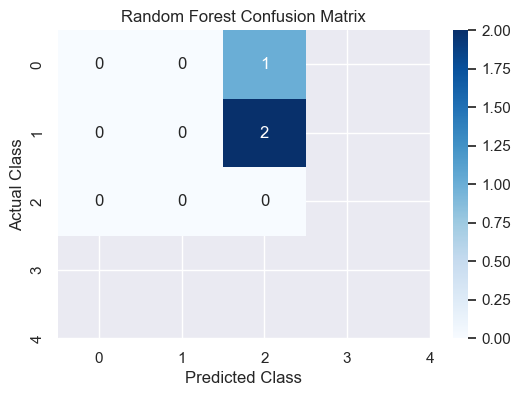

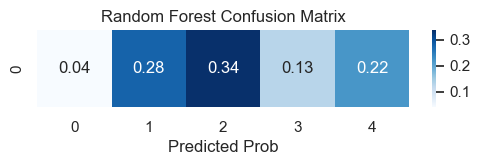

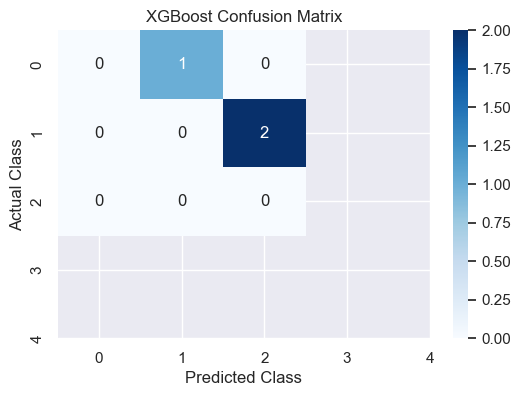

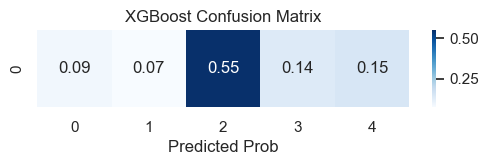

In [54]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [55]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

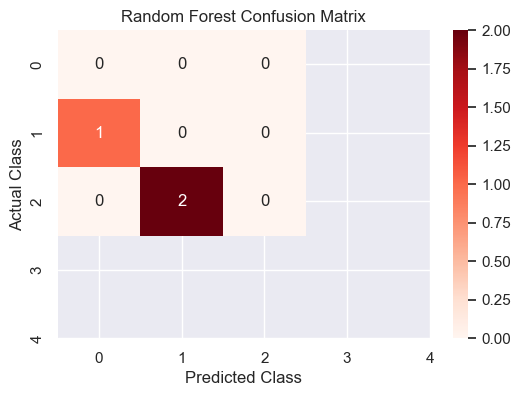

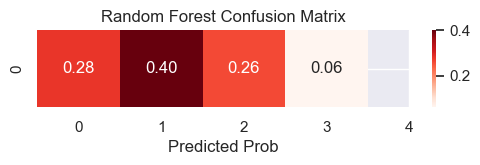

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3], got [0 1 2 4]

In [58]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [59]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [60]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [61]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

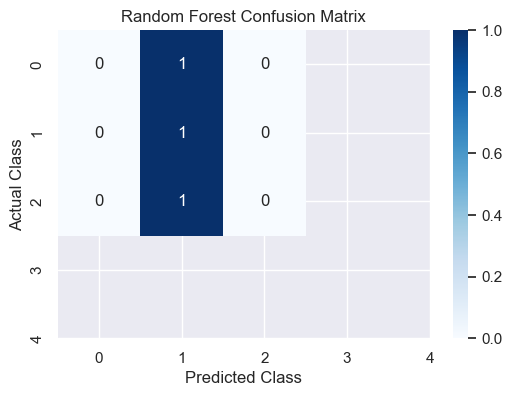

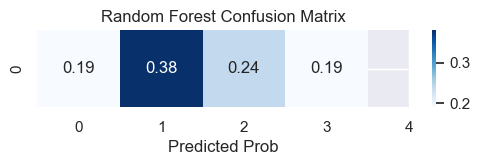

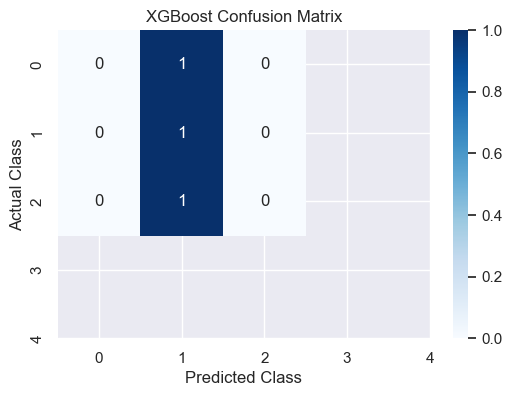

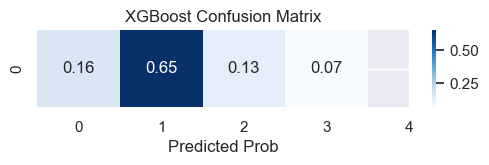

In [62]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [63]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [64]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

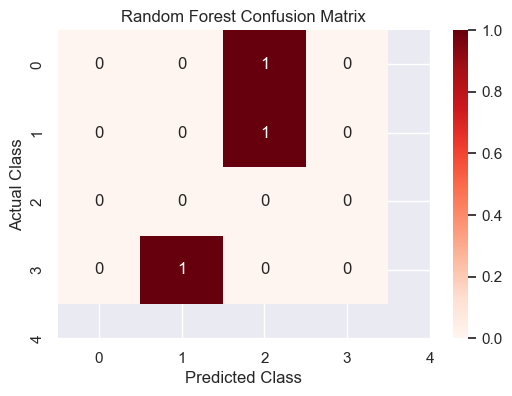

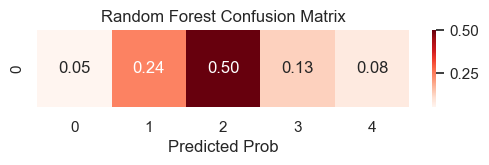

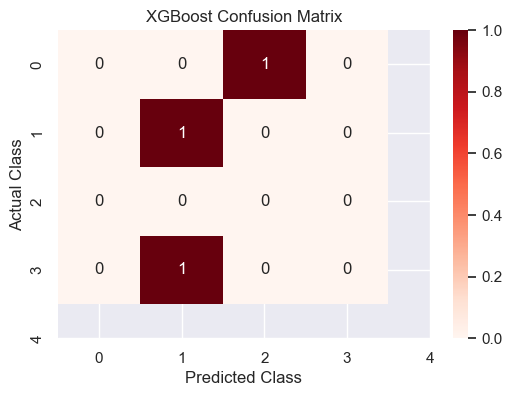

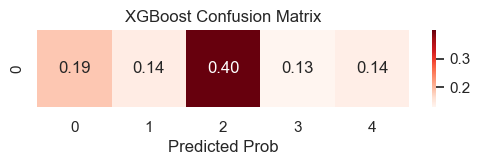

In [66]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

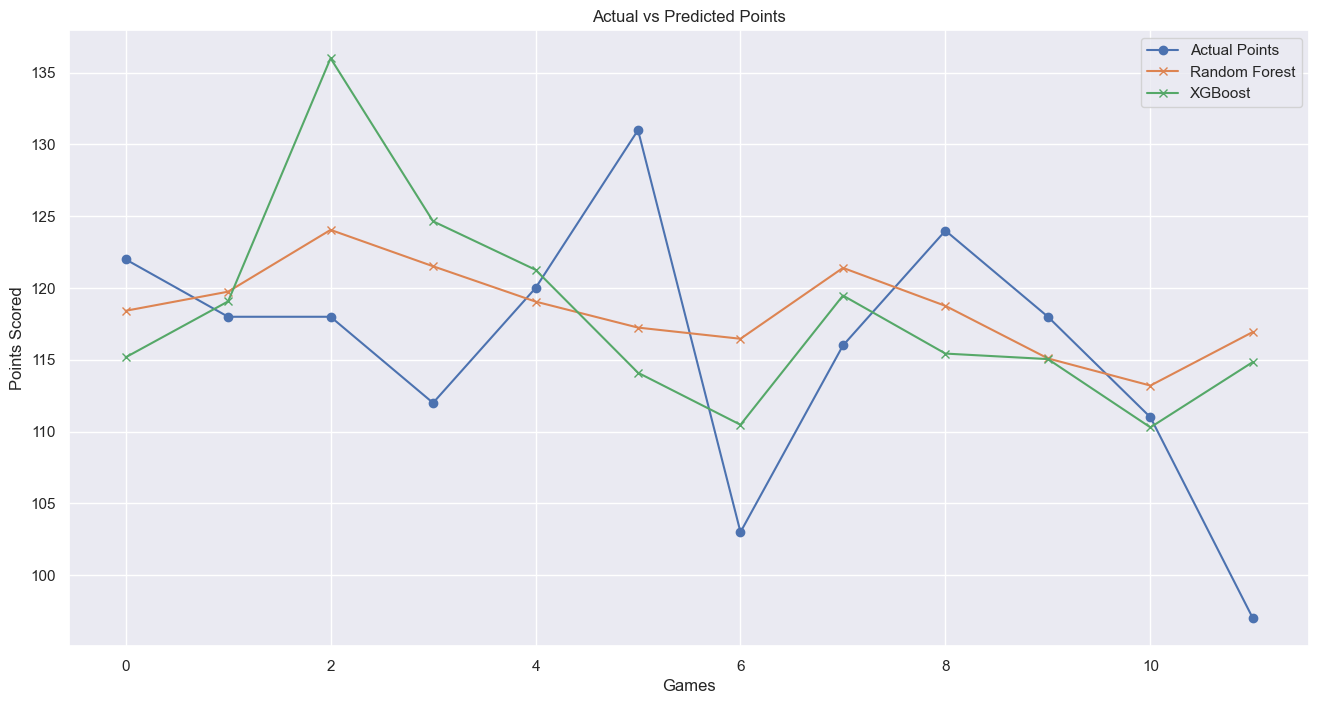

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
